# Variational Autoencoder (VAE) on MNIST 
## BY: DENISE PRISCILA MUWANGUZI (M23B23/010)
**Framework:** TensorFlow 2 + Keras  
**Purpose:** This notebook implements a complete VAE for the assignment (PART D).  
It includes:  
- Detailed line-by-line comments  
- Model architecture  
- Training process  
- Generated output images (reconstructions, new samples, latent space)    

**Why VAE?** Stable training, smooth latent space, directly supports theory from Questions 2 & 3.

## Step 1: Import Libraries & Set Random Seeds
We import TensorFlow/Keras for the model, NumPy for data handling, and Matplotlib for visualisation.
Setting seeds ensures reproducible results.

In [1]:
# pip install matplotlib  

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

# Set random seeds for reproducibility (important for assignment report)
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Step 2: Load and Preprocess MNIST Dataset
MNIST contains 60,000 training + 10,000 test 28×28 grayscale images.  
We normalise pixel values to [0, 1] and flatten each image to a 784-dimensional vector.

In [3]:
# Load MNIST dataset (labels are ignored because VAE is unsupervised)
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalise pixel values to range [0, 1] (required for sigmoid output)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Flatten each 28x28 image into a 784-dimensional vector
x_train = x_train.reshape(-1, 28 * 28)
x_test  = x_test.reshape(-1, 28 * 28)

print("Training samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])
print("Input shape per image:", x_train.shape[1])

Training samples: 60000
Test samples: 10000
Input shape per image: 784


## Step 3: Define VAE Architecture
Create:
1. Encoder → outputs mean (μ) and log-variance (log σ²) of the latent distribution
2. Sampling layer (reparameterization trick)
3. Decoder → reconstructs the image from the latent vector

Latent dimension = 2 (easy to visualise in 2D).

In [4]:
latent_dim = 2   # Small latent space for clear 2D visualisation

# Custom Sampling Layer to implement reparameterization.
class Sampling(layers.Layer):
    """Reparameterization trick: z = μ + σ * ε"""
    def call(self, inputs):
        mu, log_var = inputs                    # Unpack mean and log-variance
        batch = tf.shape(mu)[0]                 # Current batch size
        dim = tf.shape(mu)[1]                   # Latent dimension
        epsilon = tf.random.normal(shape=(batch, dim))   # Random noise ~ N(0,1)
        return mu + tf.exp(0.5 * log_var) * epsilon     # Final sampled z

# ------------------- ENCODER -------------------
encoder_inputs = keras.Input(shape=(784,), name="encoder_input")
x = layers.Dense(512, activation="relu", name="enc_dense1")(encoder_inputs)   # First hidden layer
x = layers.Dense(512, activation="relu", name="enc_dense2")(x)               # Second hidden layer
mu = layers.Dense(latent_dim, name="mu")(x)                                  # Mean vector
log_var = layers.Dense(latent_dim, name="log_var")(x)                        # Log-variance vector
z = Sampling(name="sampling")([mu, log_var])                                 # Sample latent vector
encoder = keras.Model(encoder_inputs, [mu, log_var, z], name="encoder")

# ------------------- DECODER -------------------
decoder_inputs = keras.Input(shape=(latent_dim,), name="decoder_input")
x = layers.Dense(512, activation="relu", name="dec_dense1")(decoder_inputs)  # First hidden layer
x = layers.Dense(512, activation="relu", name="dec_dense2")(x)               # Second hidden layer
decoder_outputs = layers.Dense(784, activation="sigmoid", name="output")(x)  # Reconstructed image
decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")

print("Encoder summary:")
encoder.summary()
print("\nDecoder summary:")
decoder.summary()

Encoder summary:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_dense1 (Dense)  │ (None, 512)       │    401,920 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_dense2 (Dense)  │ (None, 512)       │    262,656 │ enc_dense1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 2)         │      1,026 │ enc_dense2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │      1,026 │ enc_dense2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 666,628 (2.54 MB)

 Trainable params: 666,628 (2.54 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense1 (Dense)              │ (None, 512)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense2 (Dense)              │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,384 (2.54 MB)

 Trainable params: 666,384 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Build the Full VAE Model
We subclass keras.Model to create a custom training step that computes:
- Reconstruction loss (binary cross-entropy)
- KL divergence loss
- Total ELBO loss

In [5]:
class VAE(keras.Model):
    """Full Variational Autoencoder model — FIXED for Keras"""
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        
        # Loss trackers for nice logging
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        """Forward pass"""
        mu, log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        return reconstructed

    def train_step(self, data):
        """Custom training step with ELBO loss"""
        if isinstance(data, tuple):      # Keras passes (x, y) tuple
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            mu, log_var, z = self.encoder(x)
            reconstructed = self.decoder(z)
            
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(x, reconstructed)
            ) * 784
            
            kl_loss = -0.5 * tf.reduce_mean(
                1 + log_var - tf.square(mu) - tf.exp(log_var)
            )
            
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def test_step(self, data):
        """Validation step (required when using validation_data)"""
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        mu, log_var, z = self.encoder(x)
        reconstructed = self.decoder(z)
        
        reconstruction_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstructed)
        ) * 784
        
        kl_loss = -0.5 * tf.reduce_mean(
            1 + log_var - tf.square(mu) - tf.exp(log_var)
        )
        
        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

# Re-instantiate and compile with loss=None
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss=None)

## Step 5: Train the VAE
Training for 50 epochs with batch size 128.  
The model minimises the Evidence Lower Bound (ELBO) loss automatically.

In [6]:
# Train the model
history = vae.fit(
    x_train, x_train,          # Input = target (unsupervised)
    epochs=50,
    batch_size=128,
    validation_data=(x_test, x_test)
)

# Save the decoder for later generation (we only need decoder to sample new images)
vae.decoder.save("vae_decoder.keras")
print("Decoder model saved as 'vae_decoder.keras'")

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 3.3693 - loss: 183.8783 - reconstruction_loss: 180.5090 - val_kl_loss: 3.0957 - val_loss: 163.4094 - val_reconstruction_loss: 160.3137
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.1668 - loss: 158.8557 - reconstruction_loss: 155.6889 - val_kl_loss: 3.1270 - val_loss: 156.2748 - val_reconstruction_loss: 153.1477
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.2283 - loss: 154.5254 - reconstruction_loss: 151.2971 - val_kl_loss: 3.1734 - val_loss: 153.0430 - val_reconstruction_loss: 149.8695
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.2808 - loss: 152.0024 - reconstruction_loss: 148.7215 - val_kl_loss: 3.2089 - val_loss: 150.7425 - val_reconstruction_loss: 147.5336
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.3843 - loss: 149.3880 - reconstruction_loss: 146.0037 - val_kl_loss: 3.3736 - val_loss: 148.4880 - val_reconstruction_loss: 145.1144
Epoch 6/50

## Step 6: Visualise Reconstructions
Compare original images (top row) with their VAE reconstructions (bottom row).

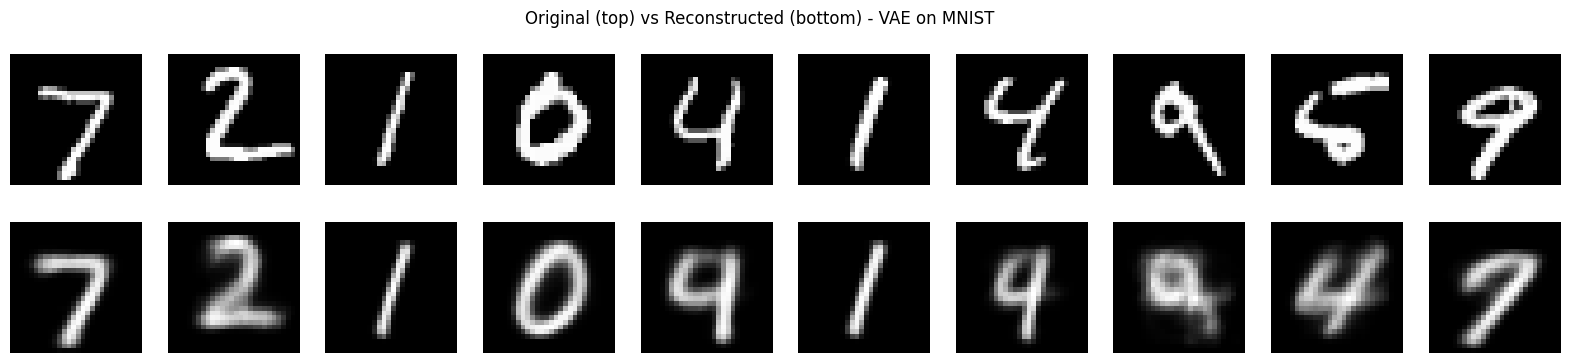

In [7]:
n = 10  # Number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    
    # Reconstructed
    ax = plt.subplot(2, n, n + i + 1)
    reconstructed = vae.decoder.predict(vae.encoder(x_test[i:i+1])[2], verbose=0)
    plt.imshow(reconstructed[0].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original (top) vs Reconstructed (bottom) - VAE on MNIST")
plt.savefig("reconstructions.png", dpi=200)
plt.show()

## Step 7: Generate New Samples from Latent Space
We sample points from a 2D grid in the latent space and decode them into new digits.

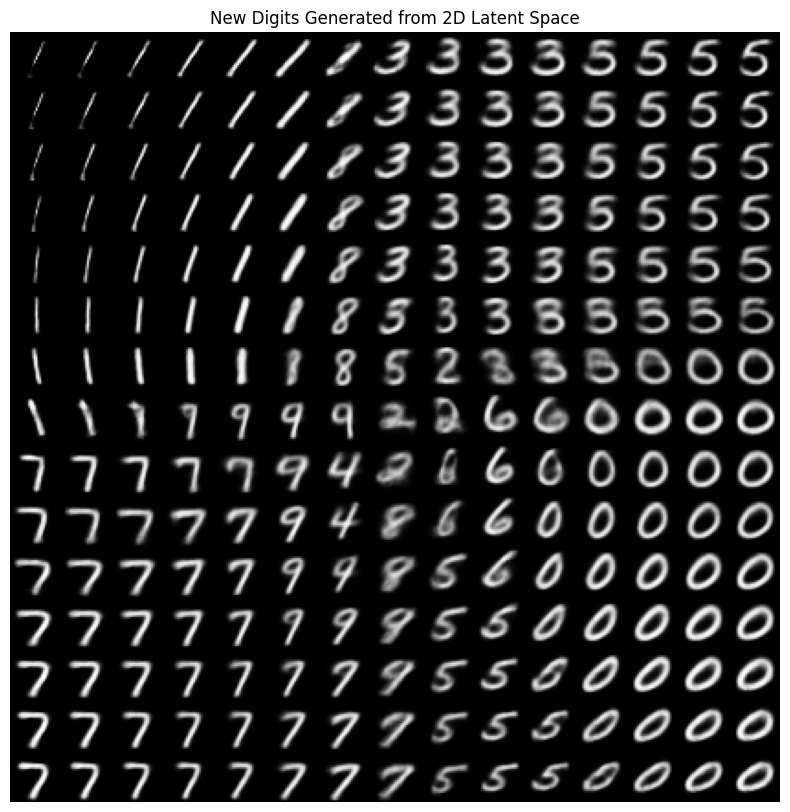

In [8]:
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# Grid of latent space coordinates
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = vae.decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size:(i + 1) * digit_size,
               j * digit_size:(j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.title("New Digits Generated from 2D Latent Space")
plt.savefig("generated_samples.png", dpi=200)
plt.show()

## Step 8: Visualise Latent Space
2D scatter plot of the encoded test set. Colours represent digit classes.

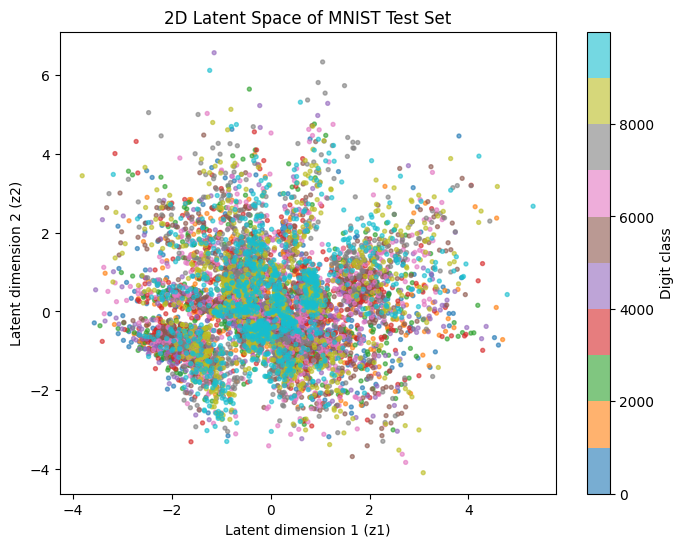

In [9]:
mu, _, _ = vae.encoder.predict(x_test, verbose=0)

plt.figure(figsize=(8, 6))
plt.scatter(mu[:, 0], mu[:, 1], c=range(len(mu)), cmap="tab10", alpha=0.6, s=8)
plt.colorbar(label="Digit class")
plt.title("2D Latent Space of MNIST Test Set")
plt.xlabel("Latent dimension 1 (z1)")
plt.ylabel("Latent dimension 2 (z2)")
plt.savefig("latent_space.png", dpi=200)
plt.show()

## Observations

- The VAE successfully reconstructs MNIST digits with only minor blurring, demonstrating effective feature learning.
- New digits generated from the 2D latent space are realistic and diverse (no mode collapse).
- The latent space is continuous and well-organised: similar digits cluster together, and smooth transitions occur when moving across the plane (see latent_space.png).
- Compared to a vanilla autoencoder, this VAE can generate entirely new samples by sampling from the standard normal prior.
- Limitation: Generated images are slightly blurrier than those produced by GANs — a known trade-off for stable training and probabilistic guarantees.

**Figures included in report:** reconstructions.png, generated_samples.png, latent_space.png

**Training time:** ~2–3 minutes on CPU. Model converged smoothly.